# W10

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from astroML.stats import sigmaG

In [5]:
prob_mat = np.array([
    [0.5, 0.5],  # (0)cloudy
    [0.1, 0.9]   # (1)clear
    ])
n_days=100000

In [8]:
def simulation_MC(n):
    states=[0]  #today cloudy

    for _ in range(1, n):
        current = states[-1]
        next_state = np.random.choice([0, 1], p=prob_mat[current])
        states.append(next_state)

    states = np.array(states)
    cum_clear = np.cumsum(states) / (np.arange(len(states)) + 1)
    return cum_clear

In [15]:
chain=simulation_MC(n_days)

Text(0, 0.5, 'cumulative clean day fraction')

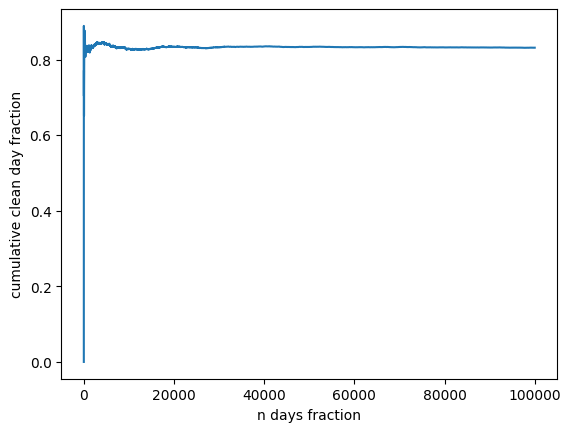

In [16]:
plt.plot(chain)
plt.xlabel('n days fraction')
plt.ylabel('cumulative clean day fraction')

(array([0.02705625, 0.        , 0.        , ..., 0.        , 0.        ,
        0.02705625]),
 array([0.00000000e+00, 3.69600370e-04, 7.39200739e-04, ...,
        8.88149688e-01, 8.88519289e-01, 8.88888889e-01]),
 <BarContainer object of 2405 artists>)

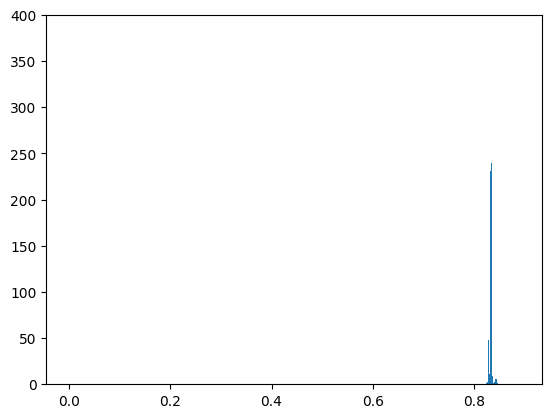

In [23]:
plt.hist(chain, bins="scott", density=True)

In [28]:
print("Statistics over the entire chain:")
print(f"Median: {np.median(chain)}")
print(f"Mean: {np.mean(chain)}")
print(f"Standard dev: {np.std(chain)}")
print(f"SigmaG error: {sigmaG(chain)}")

Statistics over the entire chain:
Median: 0.8326076858823435
Mean: 0.8325588595300986
Standard dev: 0.004914903199702498
SigmaG error: 0.0011161732211381397


### Burn_in

In [29]:
burn_in=30000
chain_b=chain[burn_in:]

(array([ 45.6007532 ,  51.6678062 , 150.30634531, 114.49116147,
        181.22874448, 313.13821941, 384.18145293,  48.14500123,
         19.37542733,  92.96290889, 246.98777056, 233.87510762,
        469.51161772, 553.27609141, 476.94865043, 599.072556  ,
        549.75328644, 371.06879   , 136.41083683, 172.22602067,
        304.72262976, 562.08310383, 557.77745332, 364.61031422,
        329.9693987 , 338.97212251, 363.4360459 , 347.97484632,
        380.0715138 , 479.88432124, 576.17432371, 329.57797592,
        265.58035233, 248.55346165, 264.01466124, 211.3682981 ,
        283.39008856, 357.76041567, 348.95340325, 191.99287077,
        160.09191467, 183.9687039 , 193.36285048, 191.01431384,
         73.97890433,  46.77502152,  55.38632256,  89.63581531,
         68.69469688,  34.24949275,  44.81790765,  72.21750185,
         63.99762359,  55.97345672,  35.0323383 ,  13.50408571]),
 array([0.83099426, 0.83106725, 0.83114025, 0.83121324, 0.83128623,
        0.83135923, 0.83143222, 0.

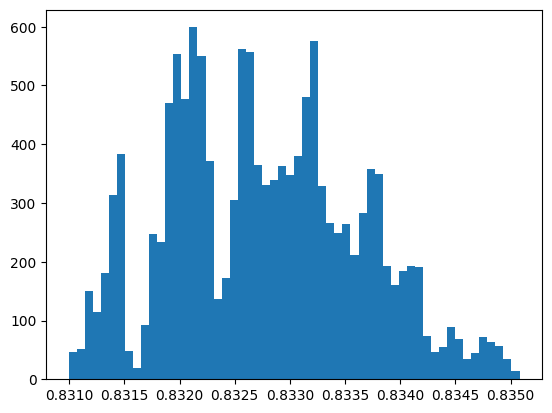

In [30]:
plt.hist(chain_b, bins="scott", density=True)

In [31]:
print("Statistics over the entire chain:")
print(f"Median: {np.median(chain_b)}")
print(f"Mean: {np.mean(chain_b)}")
print(f"Standard dev: {np.std(chain_b)}")
print(f"SigmaG error: {sigmaG(chain_b)}")

Statistics over the entire chain:
Median: 0.8327113330386902
Mean: 0.8327693668360374
Standard dev: 0.0008633809073150094
SigmaG error: 0.0009438630645821922
